# 📊 Exploratory Data Analysis (EDA)

## 1. 📂 데이터 로딩 및 기본 정보
- 파일 불러오기
- .head(), .info(), .describe() 등으로 구조 확인

---

In [56]:
# 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import platform

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, roc_curve, precision_recall_curve

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings("ignore")


# 한글 폰트 설정 (윈도우: 'Malgun Gothic', 맥: 'AppleGothic', 리눅스: 'NanumGothic')
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
# elif platform.system() == 'Darwin':
#     plt.rc('font', family='AppleGothic')
# else:
#     plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False  # 마이너스(-) 깨짐 방지


In [8]:
# 데이터 불러오기
file_path = r'D:\python\코드잇 스프린트 데분\codeit-sprint-projects\sprint-missions\스프린트 미션 13\data\raw\bank-additional-full.csv'
df = pd.read_csv(file_path, sep=';')  # 이 데이터셋은 세미콜론(;) 구분자 사용

# 기본 구조 확인
df.shape, df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

((41188, 21), None)

In [9]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [11]:
df.describe()

# 평균 나이는 약 40살

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## 2. 🧾 데이터 타입별 분류
- 범주형 / 수치형 변수 구분
- unique count 및 기본 통계량 출력

---

범주형 변수와 수치형 변수를 구분하여 주요 변수들의 분포를 시각적으로 확인해 보기로 하였습니다.

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# 수치형과 범주형 변수 구분
cat_columns = df.select_dtypes(include='object').columns.tolist()
num_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 타깃 변수는 따로 관리
if 'deposit' in cat_columns:
    cat_columns.remove('deposit')

### 2.1 범주형

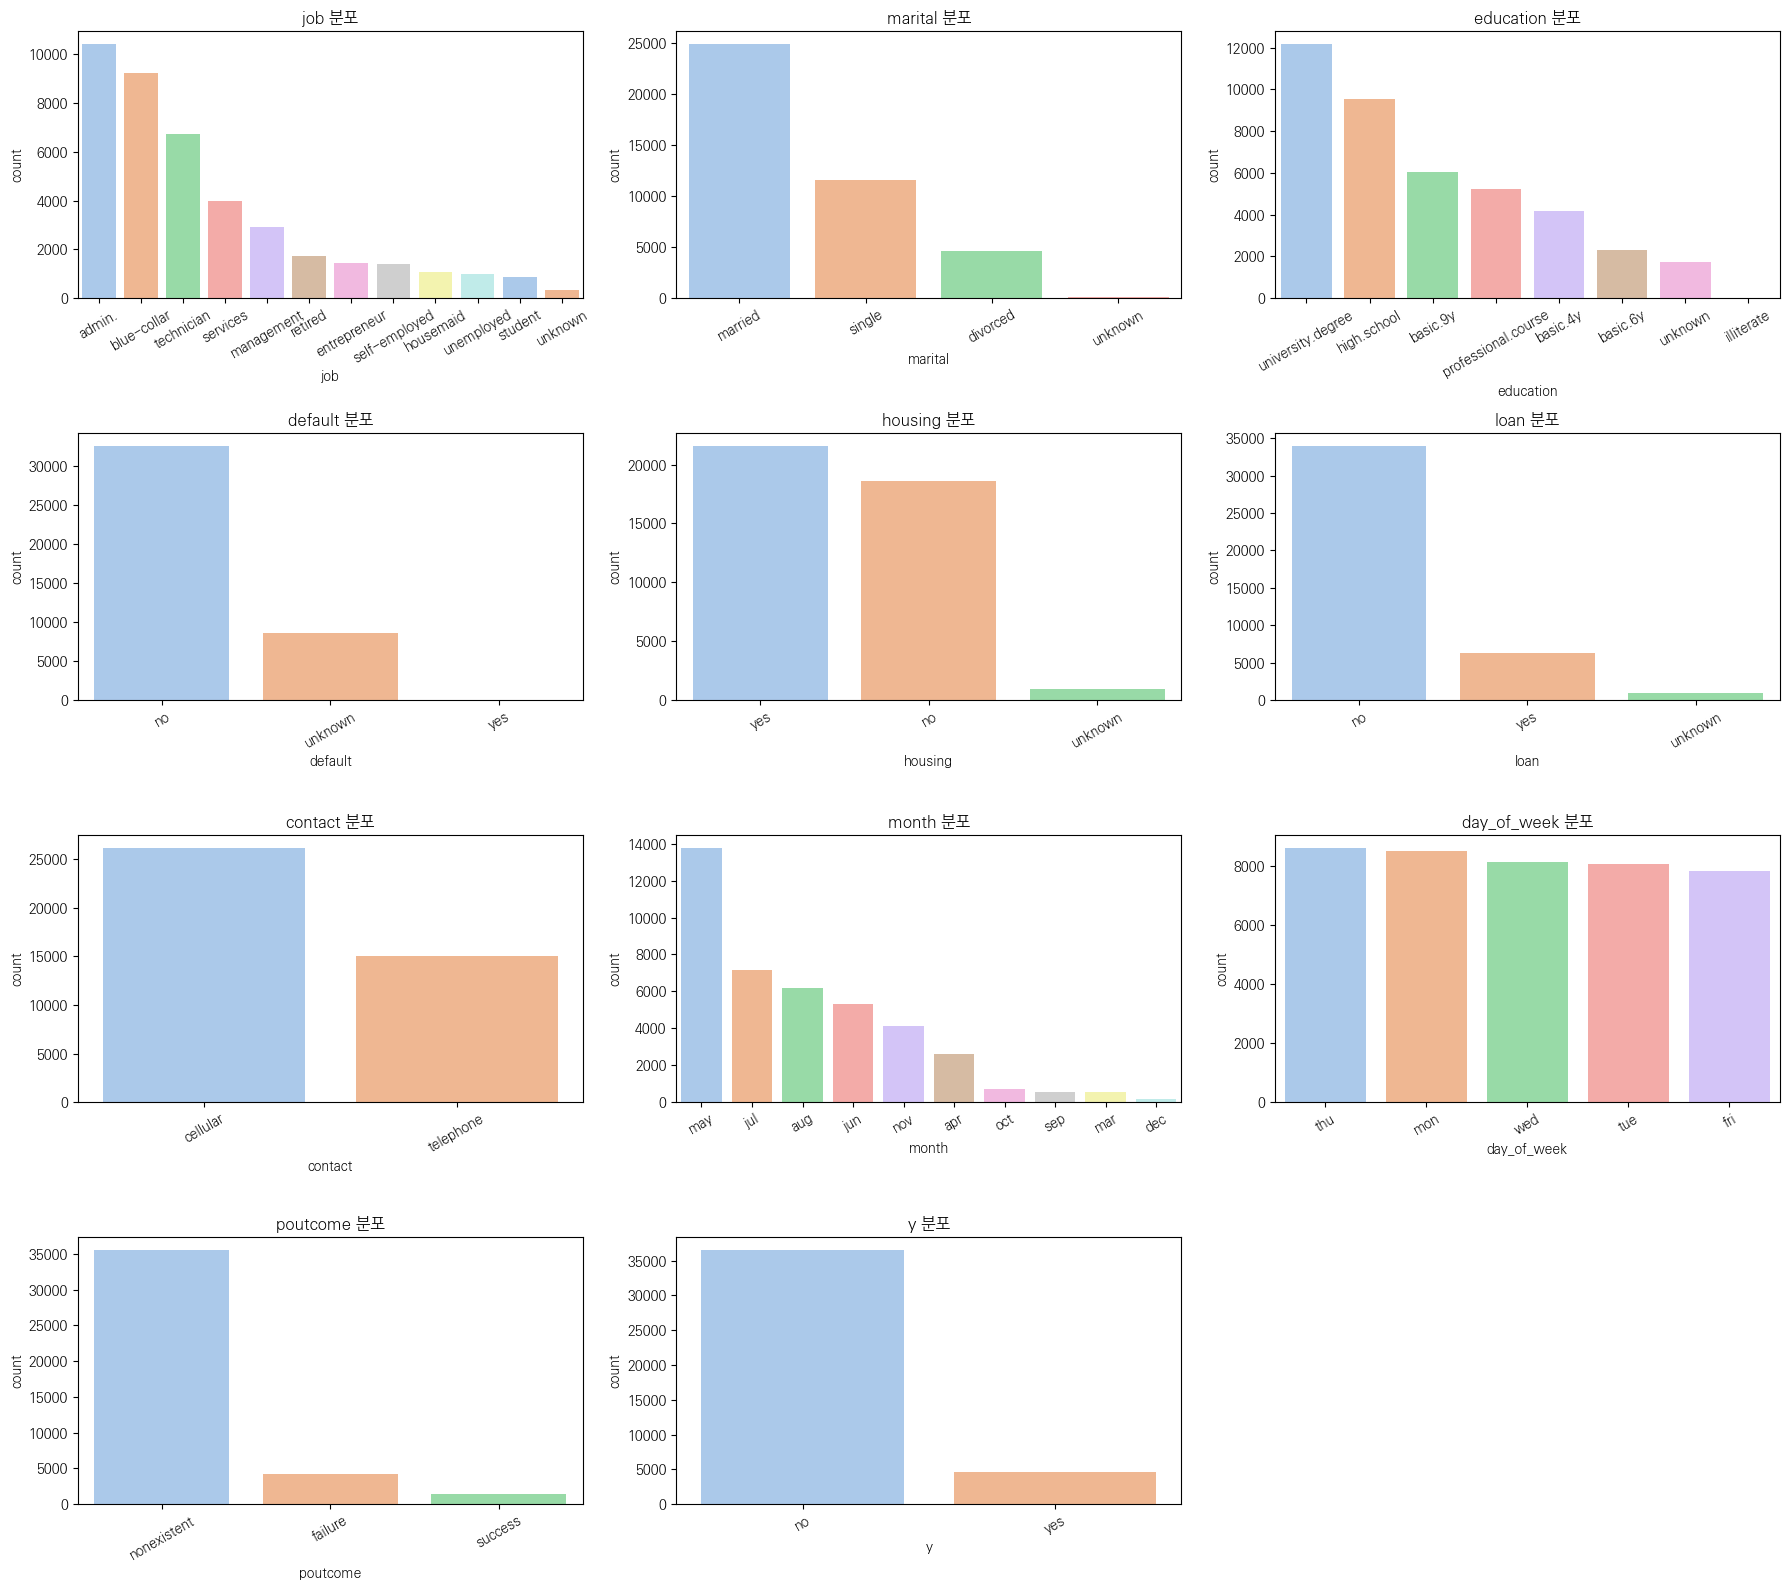

In [13]:
# 범주형 변수별 분포 확인
n_cols = 3
n_rows = -(-len(cat_columns) // n_cols)  # 올림 나눗셈

fig, axs = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axs = axs.flatten()

palette = sns.color_palette("pastel")  # 옅은 회색 계열 포함된 색상 사용

for i, col in enumerate(cat_columns):
    sns.countplot(data=df, x=col, ax=axs[i], palette=palette,
                  order=df[col].value_counts().index)
    axs[i].set_title(f'{col} 분포')
    axs[i].tick_params(axis='x', rotation=30)

# 빈 subplot 제거
for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

범주형 변수의 분포에서는 다음과 같은 경향이 보였습니다.

- 직업(job): management 직군이 가장 큰 비중을 차지하였고, blue-collar 및 services 직군도 상대적으로 높은 빈도를 보였습니다.
- 혼인 상태(marital): married 고객이 과반을 차지하였고, single과 divorced가 그 뒤를 이었습니다.
- 교육 수준(education): secondary 수준이 가장 일반적이며, tertiary 및 primary가 그 다음으로 많았습니다.
- 연락 방식(contact): 대부분의 고객이 cellular를 통해 연락되었으며, telephone과 unknown은 비교적 적은 수를 보였습니다.
- 이전 마케팅 결과(poutcome): nonexistent가 가장 큰 비중을 차지하였고, success와 failure는 소수에 해당하였습니다.

### 2.2 수치형

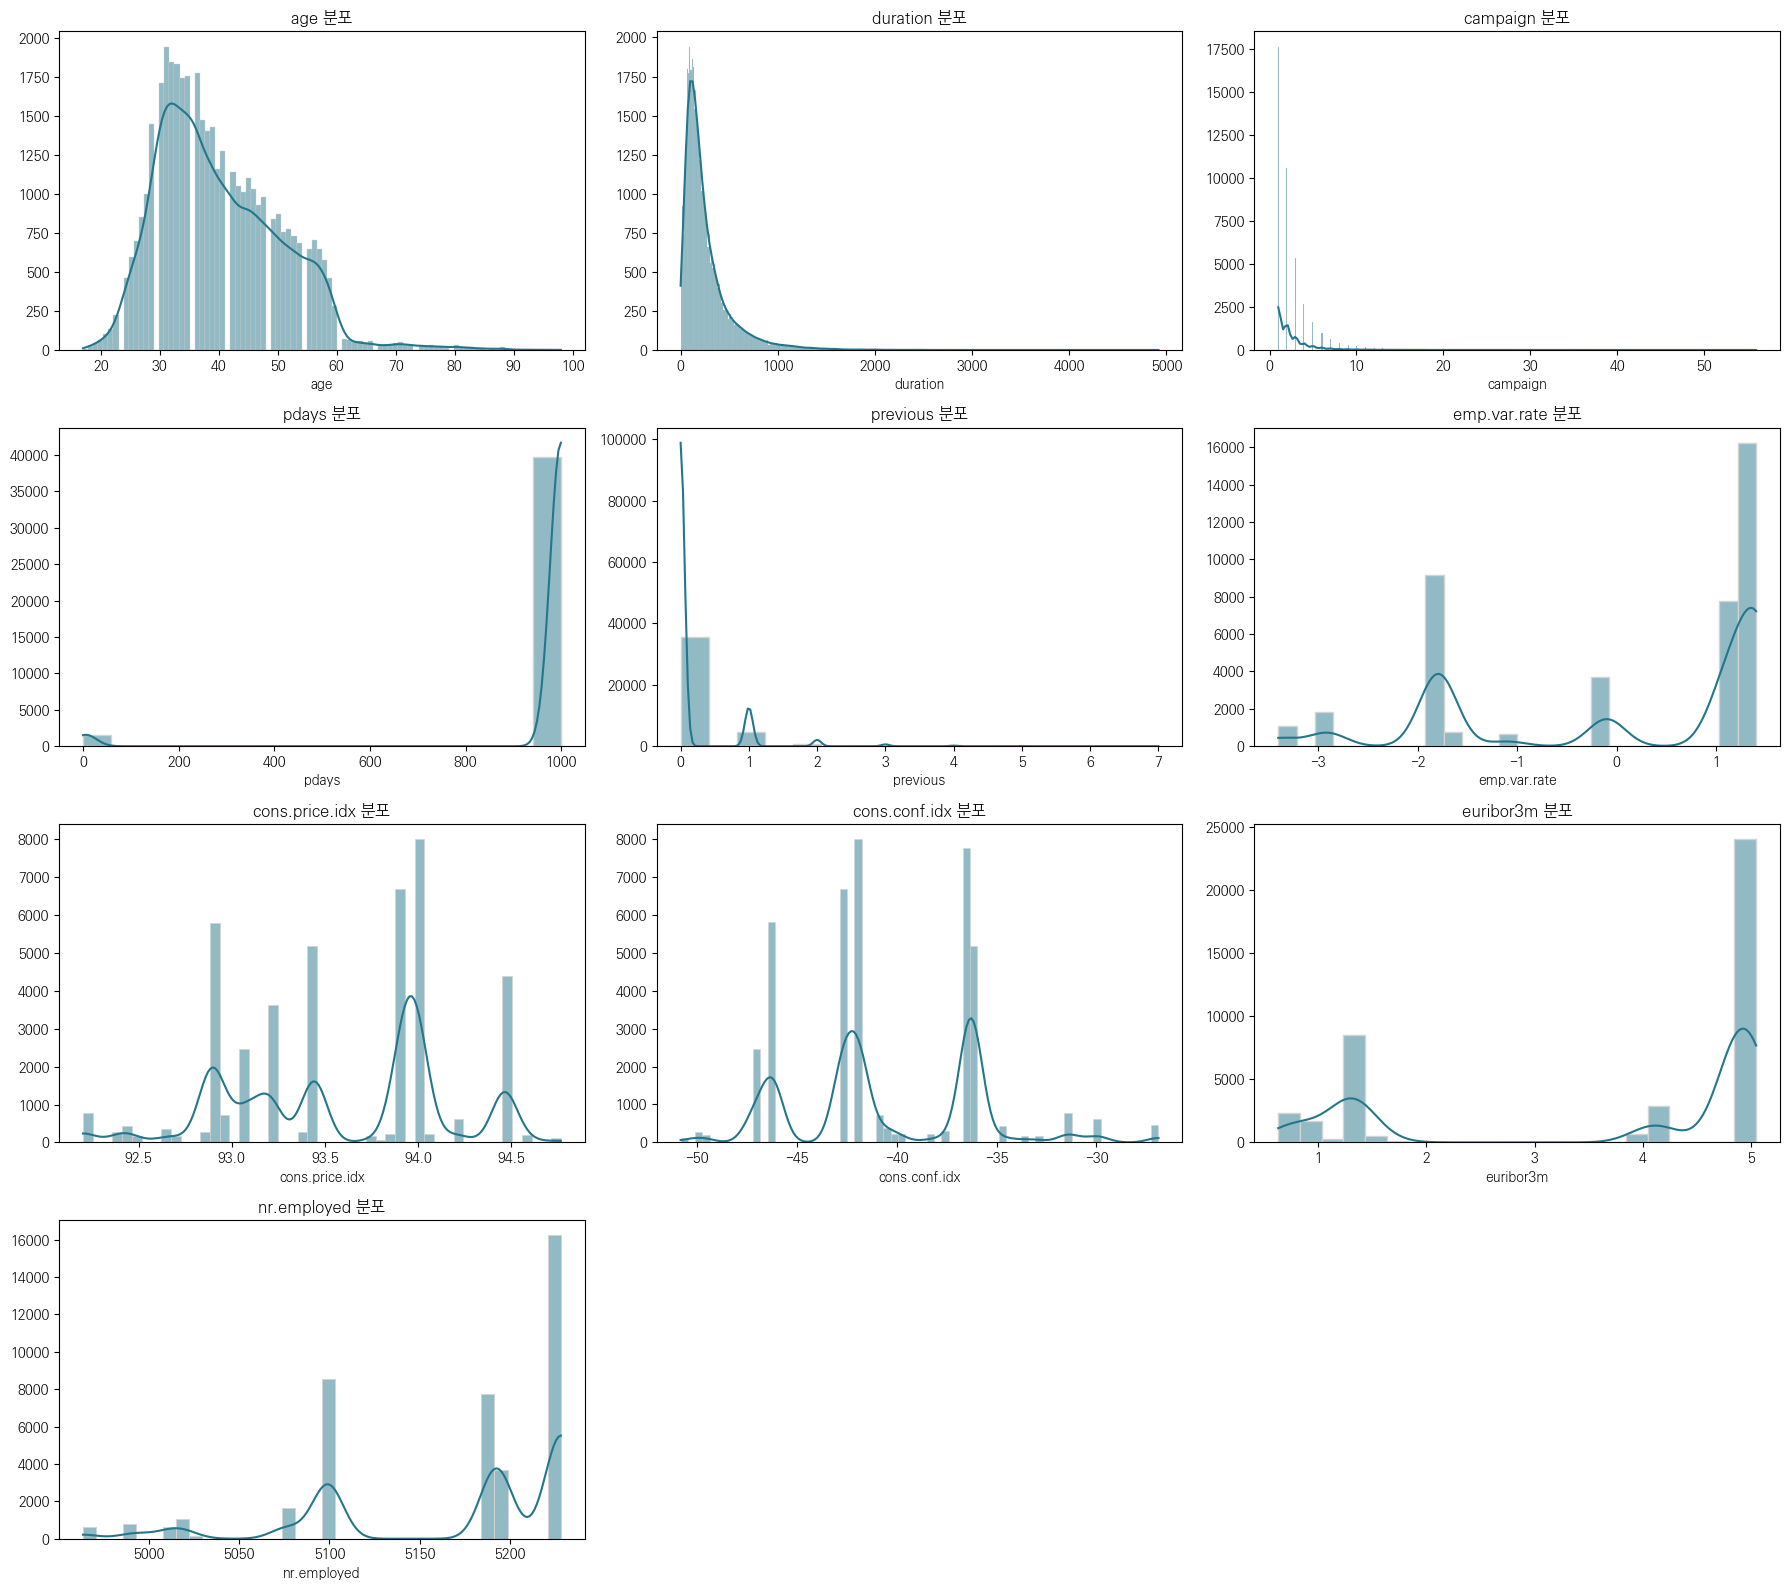

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 수치형 변수 목록 재확인
num_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'deposit' in num_columns:
    num_columns.remove('deposit')

# soft 계열의 색상 팔레트 지정
soft_palette = sns.color_palette("crest", as_cmap=True)

# 변수별 히스토그램 + KDE 시각화
n_cols = 3
n_rows = -(-len(num_columns) // n_cols)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axs = axs.flatten()

for i, col in enumerate(num_columns):
    sns.histplot(data=df, x=col, kde=True, ax=axs[i], color=soft_palette(0.6), edgecolor='lightgray')
    axs[i].set_title(f'{col} 분포')
    axs[i].set_ylabel('')
    axs[i].tick_params(axis='x', rotation=0)

# 남는 subplot 제거
for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()


수치형 변수에서는 다음과 같은 특이사항을 발견했습니다.

- `age`: 비교적 자연스러운 분포를 보였으며, 30~40대가 가장 큰 비중을 차지함. 전체적으로는 오른쪽으로 약간의 꼬리가 있는 편.
- `duration`: 극단적인 비대칭 분포를 보임. 대부분의 값이 0~500초 이내에 몰려 있음. 평균 이상의 값이 전체 분포에 큰 영향을 줄 수 있어 로그 변환 보정이 필요.  
  - 하지만 사후 정보기 때문에 모델 학습에서는 제외해야 할 것이라 생각.
- `campaign`: 연락 횟수가 대부분 1~3회에 집중되어 있으며, 10회를 초과하는 경우는 드뭄. 일부 50회 이상도 존재함 → 이상치 가능성 존재.  
  - 30 이상 정도를 이상치로 판단하여 평균 값으로 대신하는 게 좋을듯 싶음
- `pdays`: 값이 999인 데이터가 압도적으로 많음. 이는 “이전에 연락한 적 없음”을 나타내는 특수값으로, 별도 처리 필요.
  - was_contacted_before(이전에 연락 했냐) 파생변수로 1/0 구분할 예정
- `previous`: 0이 대부분이며, 이전에 연락이 있었던 고객은 소수에 해당함. 모델링 시 binary 파생 변수 고려 가능.
- `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`: 거시경제 지표들은 다봉분포(멀티모달)를 보이며, 명확한 정규분포 형태를 따르지 않음. 특히 discrete한 값으로 제한되어 있음 → 변수의 연속성이 부족하거나 데이터 수집 방식의 특징일 수 있음.

## 3. 🕵️ 범주형 변수 탐색
- `job`, `marital`, `education`, `housing`, `loan`, `contact`, `month`, `poutcome` 등
- countplot, barplot, pieplot 등 사용

---

In [18]:
print(df.columns)  # 실제 컬럼명 확인


Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')


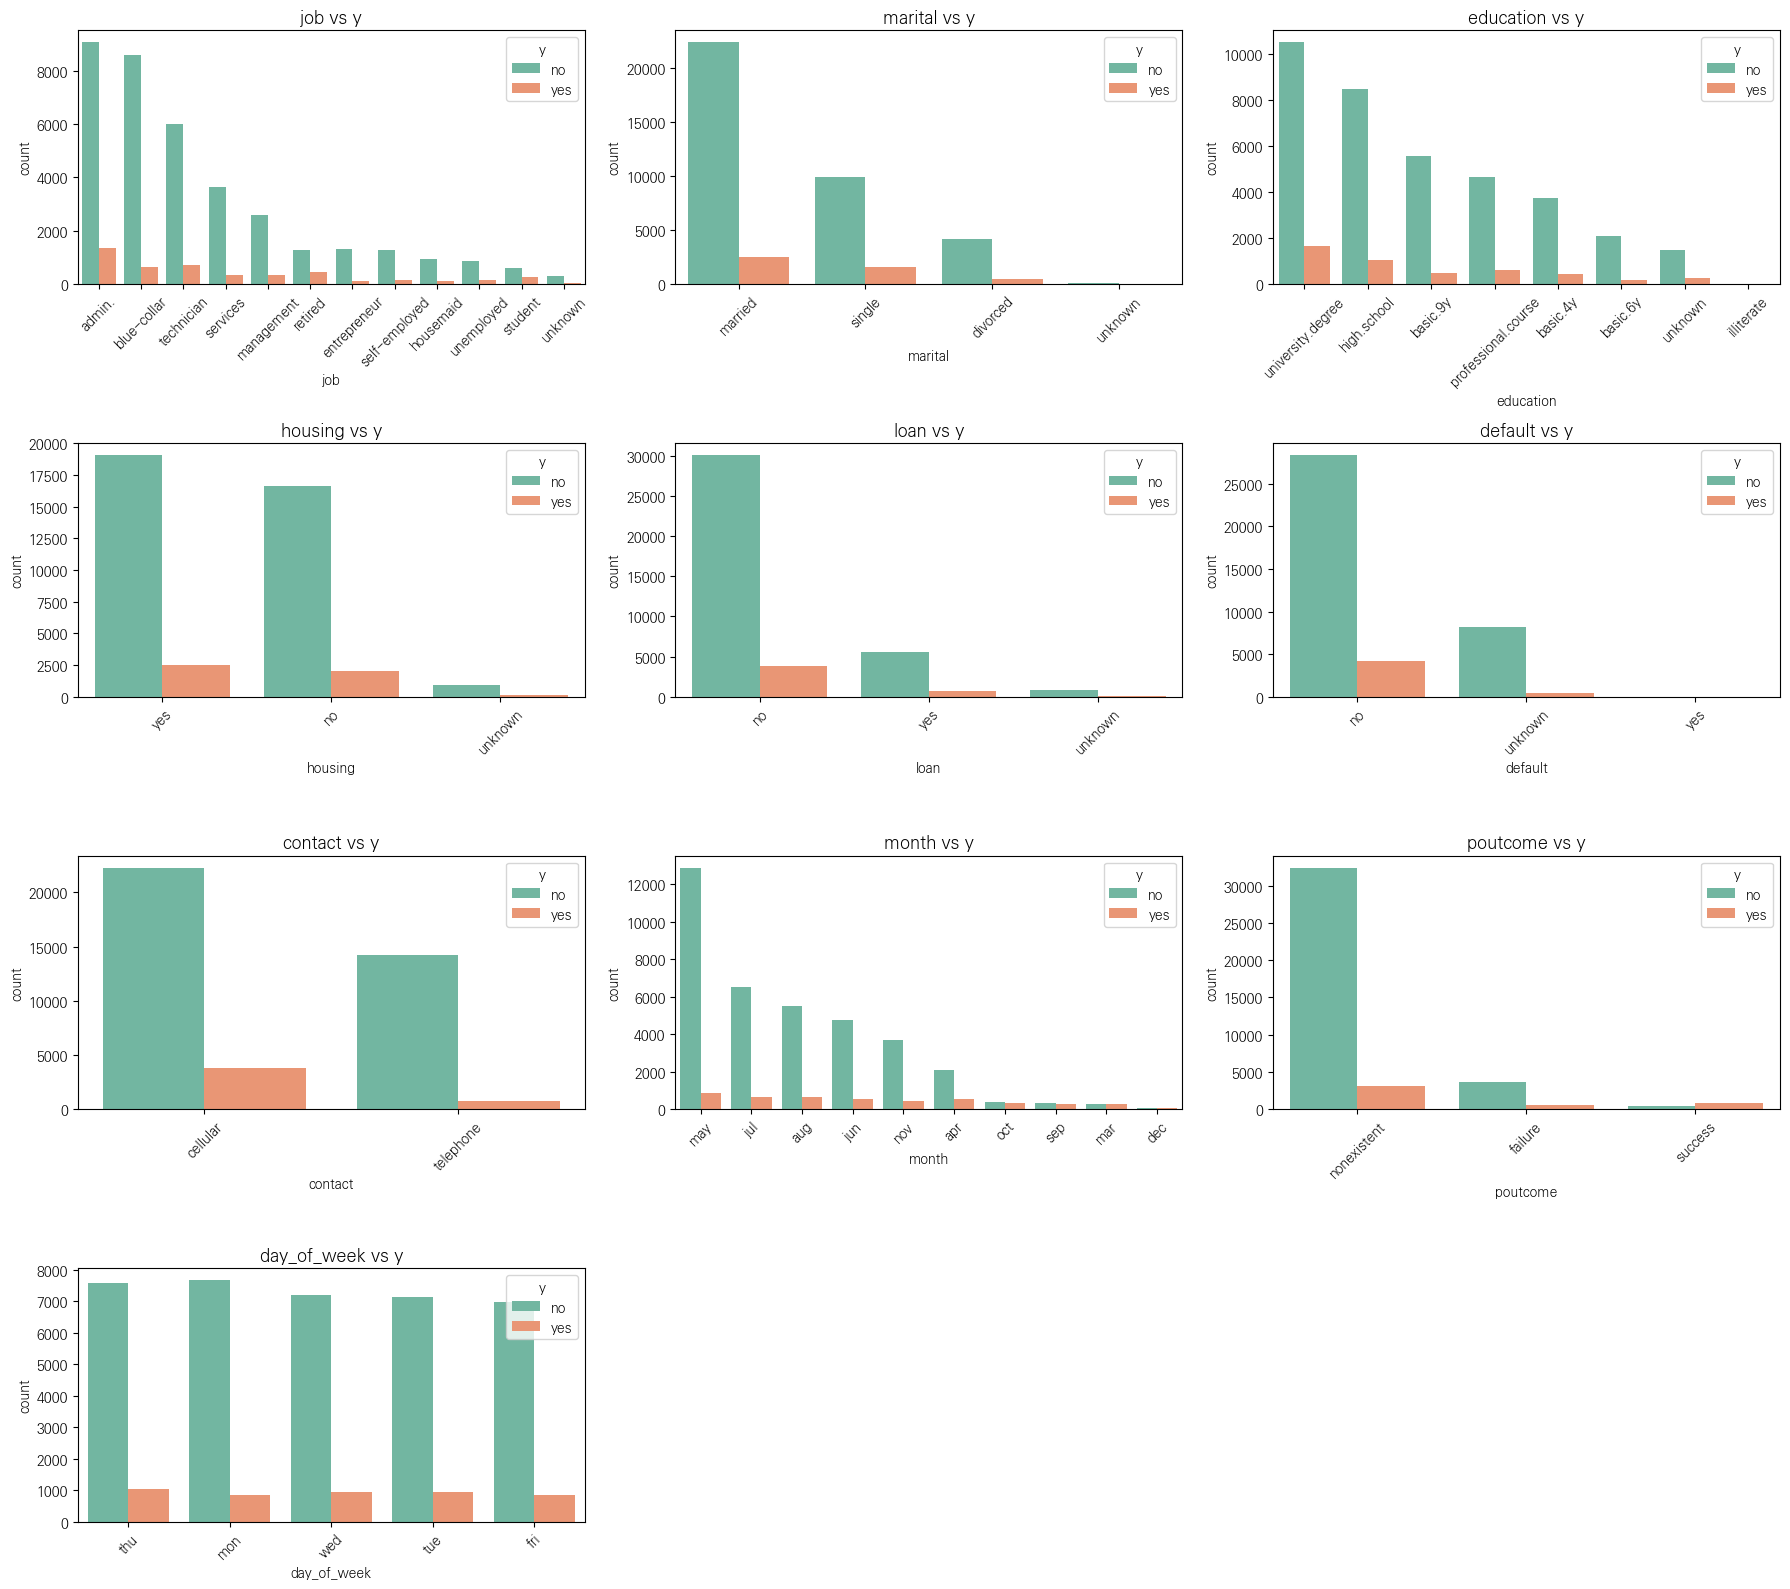

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# 확인할 주요 범주형 변수 리스트
cat_cols = [
    'job', 'marital', 'education',
    'housing', 'loan', 'default',
    'contact', 'month', 'poutcome', 'day_of_week'
]

# soft 계열 색상 팔레트 설정
soft_color = sns.color_palette("flare")[2]

# 시각화: 3열씩 나눠 그리기
n_cols = 3
n_rows = -(-len(cat_cols) // n_cols)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axs = axs.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(
        data=df, x=col, hue='y', ax=axs[i],
        palette=sns.color_palette("Set2"),
        order=df[col].value_counts().index
    )
    axs[i].set_title(f"{col} vs y", fontsize=13)
    axs[i].tick_params(axis='x', rotation=45)
    axs[i].set_ylabel("count")

# 남는 subplot 제거
for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

범주형 변수들에 대해 다음과 같은 추가 탐색을 진행하였습니다.

1. 각 범주별 `deposit=yes` 비율을 확인하고 전환율 차이를 봤습니다.
2. 일부 변수에 포함된 `unknown` 값의 빈도를 확인하여 데이터 누락 정도를 점검하였습니다.
3. `month`, `day_of_week` 를 이용하여 시기상 분포도 확인했습니다.


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib


matplotlib.rc('font', family='Pretendard-Bold')  # 윈도우: 'Malgun Gothic', 맥: 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스(-) 깨짐 방지

# 시각화 스타일
palette_color = sns.color_palette("crest")[4]
sns.set_style("whitegrid")

cat_cols = [
    'job', 'marital', 'education',
    'housing', 'loan', 'default',
    'contact', 'month', 'poutcome',
    'day_of_week'
]


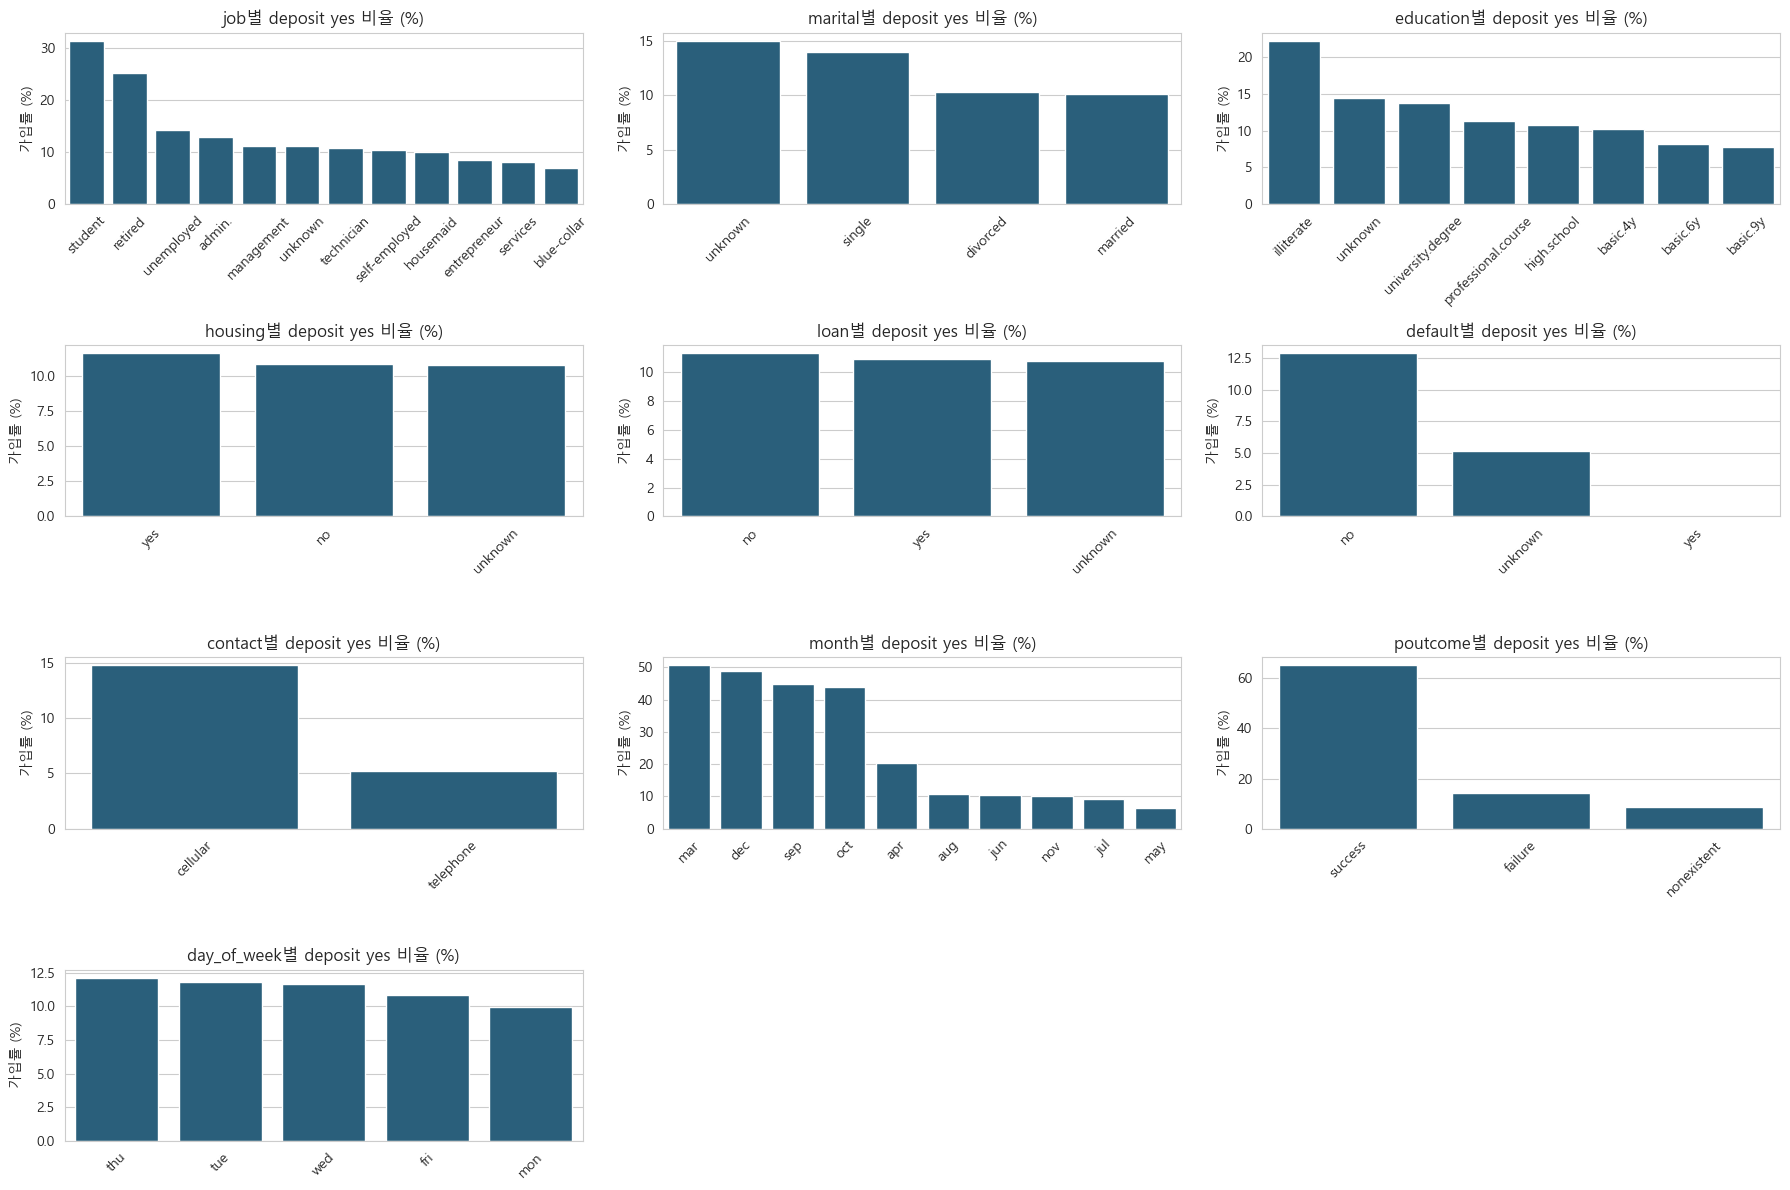

In [47]:
# -------- 1. 전환율 (deposit = yes 비율) 시각화 --------
n_cols = 3
n_rows = -(-len(cat_cols) // n_cols)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axs = axs.flatten()

for i, col in enumerate(cat_cols):
    rate = pd.crosstab(df[col], df['y'], normalize='index') * 100
    rate = rate['yes'].sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, color=palette_color, ax=axs[i])
    axs[i].set_title(f"{col}별 deposit yes 비율 (%)")
    axs[i].set_ylabel("가입률 (%)")
    axs[i].set_xlabel("")
    axs[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

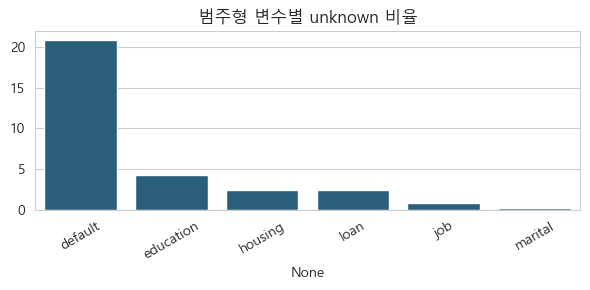

In [48]:
# -------- 2. unknown 비율 요약 (표 형태로 출력) --------
unknown_summary = {}
for col in cat_cols:
    if 'unknown' in df[col].unique():
        pct = (df[col] == 'unknown').mean() * 100
        unknown_summary[col] = round(pct, 2)

unknown_df = pd.Series(unknown_summary).sort_values(ascending=False).rename("unknown 비율 (%)").to_frame()

plt.figure(figsize=(6, 3))
sns.barplot(
    x=unknown_df.index,
    y=unknown_df["unknown 비율 (%)"].values,
    color=palette_color
)
plt.title("범주형 변수별 unknown 비율")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


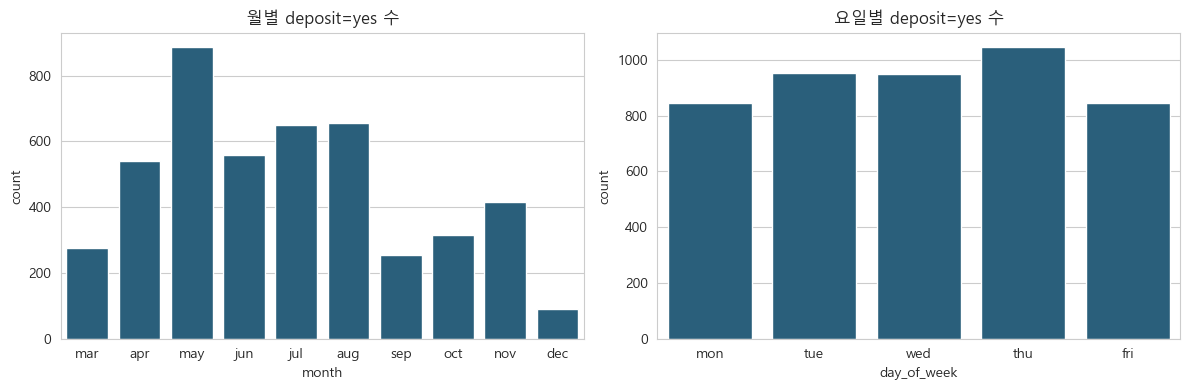

In [49]:
# -------- 3. 시기성 분석: month, day_of_week --------
month_order = ['mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
dow_order = ['mon','tue','wed','thu','fri']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df[df['y'] == 'yes'], x='month', order=month_order, color=palette_color, ax=axes[0])
axes[0].set_title("월별 deposit=yes 수")

sns.countplot(data=df[df['y'] == 'yes'], x='day_of_week', order=dow_order, color=palette_color, ax=axes[1])
axes[1].set_title("요일별 deposit=yes 수")

plt.tight_layout()
plt.show()

1. 범주별 전환율 비교 (`deposit = yes` 비율 기준)

- `job`: 학생(`student`), 은퇴자(`retired`), 실업자(`unemployed`)의 예금 가입률이 높았으며, 반대로 `blue-collar`, `entrepreneur` 등의 직군은 전환율이 낮은 편이었습니다.
- `marital`: `single` 및 `unknown` 상태에서 전환율이 다소 높았고, `married`는 가장 낮은 응답률을 보였습니다.
- `education`: `illiterate` 및 `unknown` 그룹이 높은 가입률을 보였으나, 표본 수가 매우 적어 과대해석은 유의해야 합니다.
- `contact`: `cellular` 경로에서 가입률이 높고, `telephone`은 매우 낮은 수준에 그쳤습니다.
- `month`: 3월, 12월, 9월 등에서 `deposit=yes` 비율이 높았으며, 특히 5월은 예금 유도량은 많았으나 전환율은 가장 낮은 수준이었습니다.
- `poutcome`: 이전 마케팅 결과가 `success`였던 경우 예금 가입률이 약 60% 이상으로 압도적으로 높았습니다.

2. 범주형 변수 내 `unknown` 값 분포

- `default`: 전체의 약 21%가 `unknown` 값으로, 모델 입력 시 신중한 처리 필요
- `education`, `housing`, `loan`: 각각 2~4% 수준의 `unknown` 값을 포함
- `job`, `marital` 등의 핵심 변수는 `unknown` 비율이 매우 낮아 안정적임

            → `default`는 예측력이 낮고 정보도 부족하므로 제거 또는 `has_info` 파생 변수화 가능

3. 마케팅 시기 분석

- `month`: 월별 `deposit=yes` 건수를 확인한 결과, **5월**은 연락 건수가 가장 많았으나 전환 수는 낮았고, **3월**, **12월** 등은 가입 건수 대비 높은 전환율을 보였습니다.
- `day_of_week`: 가입 수는 목요일(`thu`)에 가장 많았고, 금요일(`fri`)과 월요일(`mon`)은 상대적으로 낮은 편이었습니다.  
  다만 전체적으로는 요일별 차이가 뚜렷하지 않아 실무 영향력은 제한적일 수 있습니다.



## 4. 📈 수치형 변수 탐색
- `age`, `balance`, `day`, `duration`, `campaign`, `pdays`, `previous`
- histogram, kdeplot, boxplot, violinplot 등

---

수치형 변수와 deposit 간의 관계

수치형 변수들이 `deposit` 여부에 따라 어떤 분포 차이를 보이는지를 시각적으로 확인해 보기로 하였습니다.  
이는 가입 여부와 연관된 중심값, 이상치, 분포의 폭 등을 비교하는 데 목적이 있습니다.

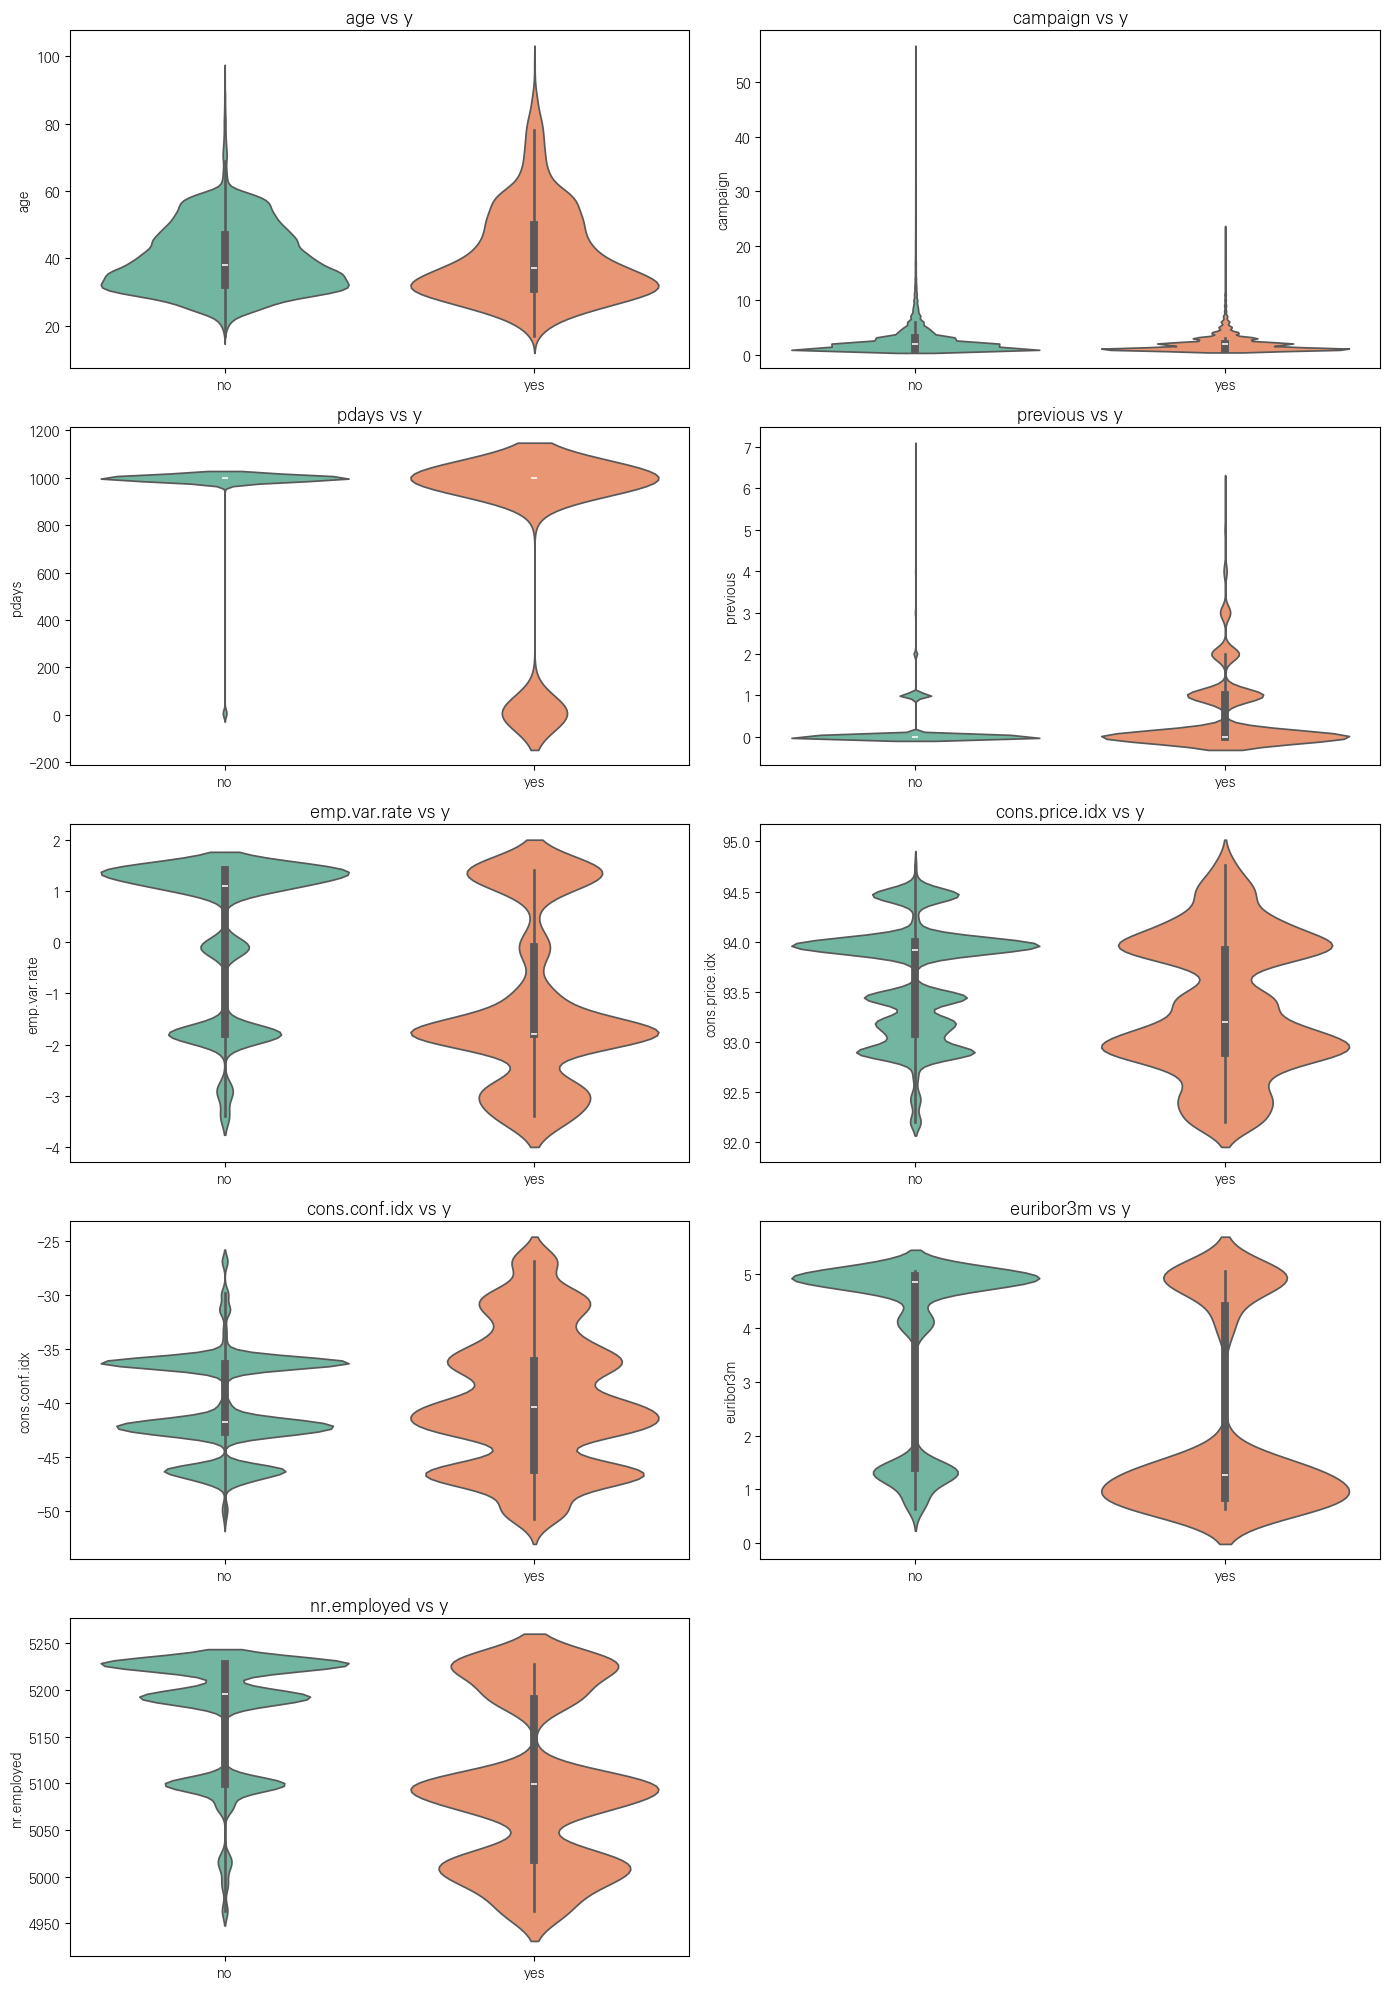

In [23]:
# 수치형 변수 목록
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'duration' in num_cols:  # duration은 예측 변수에서 제외 예정이나 지금은 포함
    num_cols.remove('duration')  # 필요시 제거
if 'deposit' in num_cols or 'y' in num_cols:
    num_cols = [c for c in num_cols if c not in ['deposit', 'y']]

# soft 색상 설정
soft_palette = sns.color_palette("Set2")

# boxplot 시각화
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 2
n_rows = -(-len(num_cols) // n_cols)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axs = axs.flatten()

for i, col in enumerate(num_cols):
    sns.violinplot(data=df, x='y', y=col, ax=axs[i], palette=soft_palette)
    axs[i].set_title(f"{col} vs y", fontsize=13)
    axs[i].set_xlabel('')
    axs[i].set_ylabel(col)

# 빈 subplot 제거
for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()


각 수치형 변수의 `deposit` 응답에 따른 분포 차이를 확인한 결과, 다음과 같은 특이점을 관찰할 수 있었습니다.

 이상치
  - `campaign`: 40~50 이상은 분포상 명백한 이상치로 보임  
  - `pdays`: 1000에 수렴하는 값들이 명확하게 쏠려 있으며, 의미상도 특별값으로 분리 필요  
  - `age`는 상한은 자연스럽고 하한도 18세로 제한되어 있어 이상치는 없음

전처리 제안 요약
  - `campaign`: 상한값 제한 (예: 30 이상 대체 또는 제거)
  - `pdays`: `999` 여부 기준 이진 파생 변수 생성 (`was_contacted_before`)
  - `previous`: 0 vs 1+ 기준 이진화 가능
  - `age`: 연령 구간화 및 고령 여부 파생 가능
  - `euribor3m`: 주요 설명 변수로 유지. 필요 시 변동성 구간 분리 가능

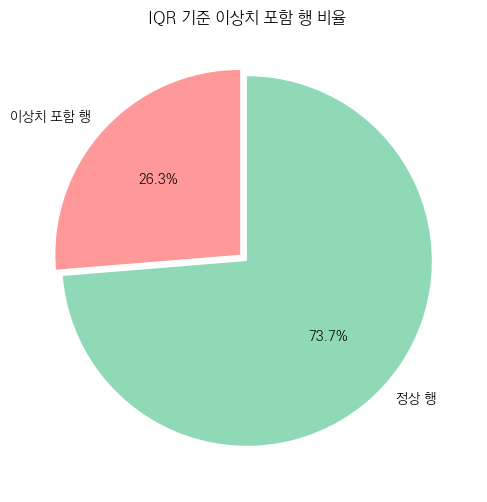

이상치 포함 행: 10828 / 전체: 41188 (26.29%)


In [28]:
# IQR 기반 이상치가 하나라도 포함된 행의 비율 파이차트로 시각화

# 이상치 마스크 생성 (각 열별)
outlier_mask_df = pd.DataFrame(False, index=df.index, columns=num_columns)
for col in num_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_mask_df[col] = (df[col] < lower) | (df[col] > upper)

# 이상치가 하나라도 있는 행
outlier_row_mask = outlier_mask_df.any(axis=1)
n_outlier_rows = outlier_row_mask.sum()
n_total = len(df)

# 파이차트 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.pie(
    [n_outlier_rows, n_total - n_outlier_rows],
    labels=['이상치 포함 행', '정상 행'],
    autopct='%1.1f%%',
    colors=['#ff9999', '#8fd9b6'],
    startangle=90,
    explode=(0.05, 0)
)
plt.title('IQR 기준 이상치 포함 행 비율')
plt.show()

print(f"이상치 포함 행: {n_outlier_rows} / 전체: {n_total} ({n_outlier_rows/n_total:.2%})")

In [29]:
# 컬럼별 이상치 개수와 비율을 데이터프레임으로 정리
outlier_stats = pd.DataFrame({
    'column': num_columns,
    'outlier_count': outlier_counts,
    'outlier_ratio': [cnt / n_total for cnt in outlier_counts]
})

# 이상치 비율 기준 내림차순 정렬
outlier_stats_sorted = outlier_stats.sort_values(by='outlier_count', ascending=False)

# 결과 출력
print(outlier_stats_sorted[['column', 'outlier_count', 'outlier_ratio']])

           column  outlier_count  outlier_ratio
4        previous           5625       0.136569
1        duration           2963       0.071938
2        campaign           2406       0.058415
3           pdays           1515       0.036783
0             age            469       0.011387
7   cons.conf.idx            447       0.010853
5    emp.var.rate              0       0.000000
6  cons.price.idx              0       0.000000
8       euribor3m              0       0.000000
9     nr.employed              0       0.000000


`previous` -> 이진화 처리 예정  
`duration` -> 전후관계 맞지 않아 컬럼 삭제 예정  
`campaign` -> 30 이상 값 제거 예정

수치형 변수 추가 탐색

1. duration 분석
`duration`은 예측 불가능한 사후 변수이기 때문에 모델 입력에서는 제외할 예정이지만,  
가입 여부와의 관계가 매우 강하므로 분석 차원에서는 그 영향력을 충분히 파악할 필요가 있습니다.

1. 수치형 변수 간 상관관계
모든 수치형 변수들 간의 피어슨 상관계수를 heatmap으로 시각화하여 변수 간 선형 관계 구조를 확인하였습니다.

1. 주요 변수별 전환율 비교
전환율에 영향을 줄 수 있는 주요 수치형 변수들을 중심으로, 특정 구간 조건 하에서 가입률 차이를 확인해보았습니다.
예: `campaign` ≤ 3, `pdays` ≠ 999, `previous` > 0 등


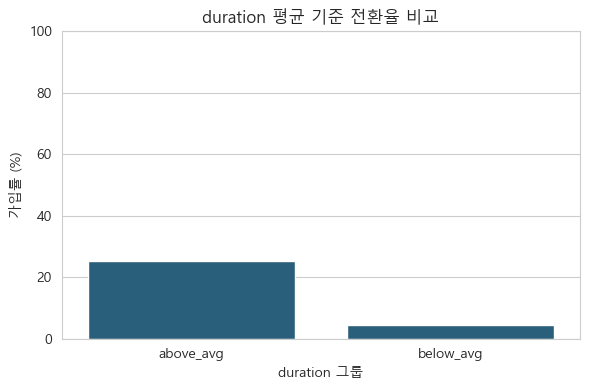

In [57]:
### 1. duration 분석 (전환율 관점)
avg_duration = df['duration'].mean()
df['duration_group'] = df['duration'].apply(lambda x: 'above_avg' if x > avg_duration else 'below_avg')

duration_ratio = pd.crosstab(df['duration_group'], df['y'], normalize='index') * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=duration_ratio.index, y=duration_ratio['yes'], color=palette_color)
plt.title("duration 평균 기준 전환율 비교")
plt.ylabel("가입률 (%)")
plt.xlabel("duration 그룹")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

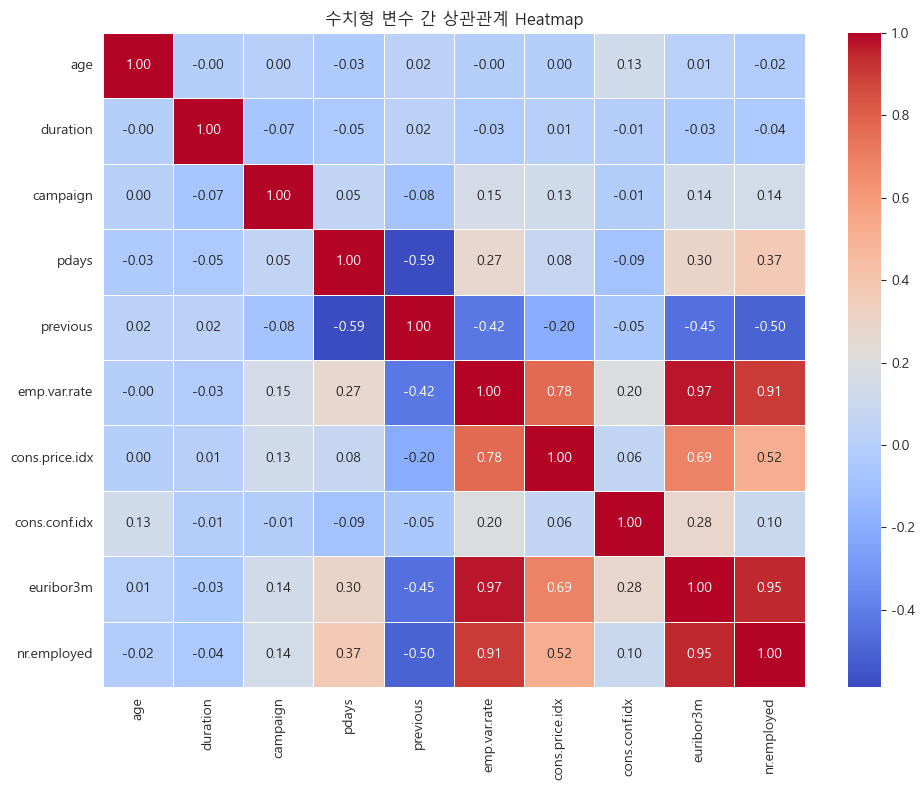

In [58]:
### 2. 수치형 변수 상관관계 heatmap
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c not in ['deposit']]  # y 제외

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
plt.title("수치형 변수 간 상관관계 Heatmap")
plt.tight_layout()
plt.show()


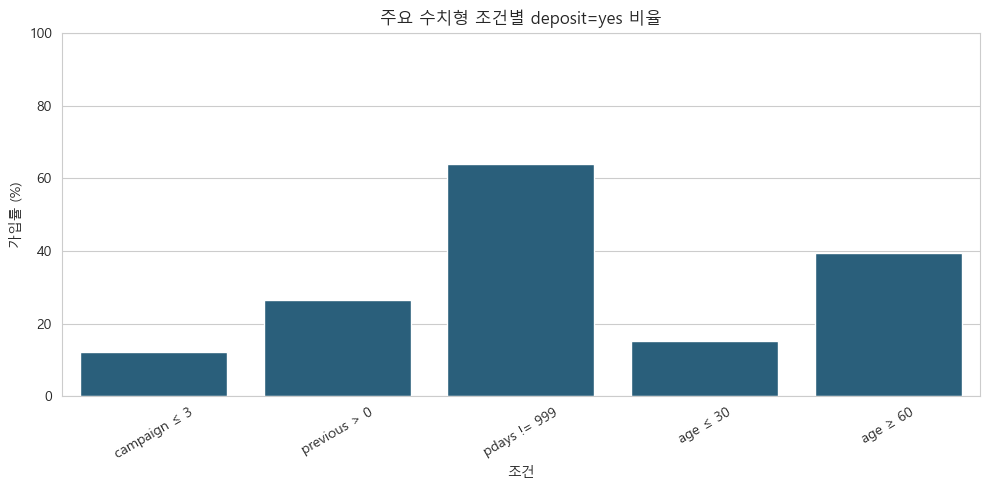

,조건,가입률 (%),대상 수
0,campaign ≤ 3,12.17,33553
1,previous > 0,26.65,5625
2,pdays != 999,63.83,1515
3,age ≤ 30,15.22,7383
4,age ≥ 60,39.56,1193


In [60]:
### 3. 주요 변수별 전환율 비교

# 조건 정의: 특정 구간에서 전환율 계산
def calc_ratio(col, condition):
    subset = df[condition]
    total = len(subset)
    yes = (subset['y'] == 'yes').sum()
    ratio = yes / total * 100 if total > 0 else 0
    return round(ratio, 2), total

# 비교 조건 리스트
conditions = {
    'campaign ≤ 3': df['campaign'] <= 3,
    'previous > 0': df['previous'] > 0,
    'pdays != 999': df['pdays'] != 999,
    'age ≤ 30': df['age'] <= 30,
    'age ≥ 60': df['age'] >= 60
}

# 결과 저장
result = []
for label, cond in conditions.items():
    ratio, total = calc_ratio('y', cond)
    result.append((label, ratio, total))

# 결과 시각화
result_df = pd.DataFrame(result, columns=['조건', '가입률 (%)', '대상 수'])

plt.figure(figsize=(10, 5))
sns.barplot(data=result_df, x='조건', y='가입률 (%)', color=palette_color)
plt.title("주요 수치형 조건별 deposit=yes 비율")
plt.xticks(rotation=30)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# 결과 표도 함께 출력
result_df

 duration 분석

- 평균 duration보다 긴 그룹의 예금 가입률은 약 25%, 짧은 그룹은 5% 미만으로 큰 차이를 보였음.
- `duration`은 예측 시 사용할 수는 없지만, 전환율에 강한 영향을 주는 사후 변수임.

수치형 변수 간 상관관계

- `euribor3m`, `emp.var.rate`, `nr.employed`는 서로 강한 양의 상관관계 (r > 0.9)를 보임.
- `pdays`와 `previous`는 음의 상관관계 (r ≈ -0.59)로 나타났으며, 이 둘은 과거 캠페인 경험과 관련된 변수로 해석됨.
- `age`, `duration`, `campaign` 등은 대부분 다른 변수들과 상관도가 낮아 독립적인 입력 변수로 유지 가능함.

 주요 변수별 전환율

- `pdays ≠ 999`: 과거에 마케팅 연락을 받은 이력이 있는 고객은 약 **64%**의 가입률을 보여, 강한 양의 관계
- `age ≥ 60`: 고령 고객은 **약 40%** 수준의 전환율로, 평균보다 뚜렷, 높은 가입 경향
- `previous > 0`: 이전 캠페인에서 접촉 경험이 있는 고객도 약 **28%**로, 없는 고객 대비 높은 편
- `campaign ≤ 3`: 3회 이하 연락 고객의 전환율은 약 **13%**로, 전체 평균 수준보다 다소 높은 수준
- `age ≤ 30`: 젊은 층은 전환율이 **15% 이하**로, 고령층 대비 가입 가능성이 낮은 편

## 5. 변수 정리 (eda 기반 전처리 계획서)

---


| 변수명                            | 타입  | 설명            | 주요 특이점 및 해석 요약                                         | 전처리 및 파생 변수 계획                                           |
| ------------------------------ | --- | ------------- | ------------------------------------------------------ | -------------------------------------------------------- |
| `age` (에이지)                    | 수치형 | 나이            | 고령층(`≥60`) 전환율 높음. 젊은 층(`≤30`) 낮음                      | **구간화** (예: 10년 단위) + `is_senior` 파생 가능                  |
| `job` (잡)                      | 범주형 | 직업            | `student`, `retired`, `unemployed` 전환율 높음. 일부 희소 범주 존재 | 희소범주 정리 or 그룹화. One-hot 인코딩 예정                           |
| `marital` (머리털)                | 범주형 | 결혼 상태         | `single` > `divorced` > `married` 순 전환율. `unknown` 있음  | one-hot 인코딩. `unknown` 포함 유지 또는 결측 마스킹 변수화 가능            |
| `education` (에듀케이션)            | 범주형 | 교육 수준         | `illiterate` 매우 높은 전환율이나 표본 수 극소. `unknown` 존재         | one-hot 인코딩. `unknown`, `illiterate` 희소 처리 고려            |
| `default` (디폴트)                | 범주형 | 신용 불량 여부      | `yes` 거의 없음. 대부분 `no` 또는 `unknown`                     | **제외 고려** 또는 `has_default_info` 이진 파생 변수 생성              |
| `housing` (하우징)                | 범주형 | 주택 대출 여부      | `yes` 그룹이 `no`보다 전환율 낮음                                | one-hot 인코딩. `unknown` 존재 → 결측 처리 여부 검토                  |
| `loan` (론)                     | 범주형 | 개인 대출 여부      | `no`가 많고 `yes`는 소수. `unknown` 소폭 존재                    | one-hot 인코딩. `unknown` 포함 유지 or 마스킹                      |
| `contact` (컨택트)                | 범주형 | 연락 수단         | `cellular` 전환율 높음. `telephone`은 매우 낮음                  | one-hot 인코딩                                              |
| `month` (먼스)                   | 범주형 | 마지막 연락 월      | 3, 12월 전환율 높고, 5월은 매우 낮음. 계절성 있음                       | **순서형 처리 고려** or one-hot 인코딩. 월 순서 정렬 유지                 |
| `day_of_week` (데이 오브 위크)       | 범주형 | 마지막 연락 요일     | 요일별 차이 크지 않음. 목요일 약간 높음                                | one-hot 인코딩                                              |
| `duration` (듀레이션)              | 수치형 | 통화 시간 (초)     | **전환율과 매우 높은 상관** (예측 불가 변수)                           | ❗ **모델 입력 제외** (평가용으로만 사용)                               |
| `campaign` (캠페인)               | 수치형 | 연락 횟수         | 과도한 연락 시 전환율 하락. `≤3`일 때 전환율 높음                        | **상한값 제한** (예: 15 이상 클립), 로그변환 or `is_low_contact` 파생 가능 |
| `pdays` (피데이즈)                 | 수치형 | 이전 연락 후 지난 일수 | `999`이 대부분 (미연락 의미). 그 외는 전환율 매우 높음                    | `was_contacted_before` (999 제외 여부) 이진 파생 변수              |
| `previous` (프리비어스)             | 수치형 | 이전 캠페인 연락 횟수  | `>0`인 경우 전환율 높음. 0이 대부분                                | `had_previous_contact` 이진 파생 변수 생성                       |
| `poutcome` (파웃컴)               | 범주형 | 이전 캠페인 결과     | `success`일 경우 전환율 60%↑, `failure`/`nonexistent` 낮음     | one-hot 인코딩 or 3단계 순서형 처리 가능                             |
| `emp.var.rate` (엠프 바리에이션 레이트)  | 수치형 | 고용 변동률        | `euribor3m`, `nr.employed`와 강한 양의 상관관계                 | 그대로 유지. 필요 시 PCA 포함 고려                                   |
| `cons.price.idx` (콘스 프라이스 인덱스) | 수치형 | 소비자 물가지수      | 구간 단위로 분포함. `emp.var.rate`와도 높은 상관관계                   | 그대로 유지 or 정규화                                            |
| `cons.conf.idx` (콘스 컨피던스 인덱스)  | 수치형 | 소비자 신뢰지수      | 뚜렷한 영향은 없음. 다만 평균 차이 존재                                | 그대로 유지. 로그변환 가능성 낮음                                      |
| `euribor3m` (유리보 쓰리엠)          | 수치형 | 3개월 유리보 금리    | 전환율과 관계 있음. 낮은 금리에서 가입률 높음                             | 그대로 유지 or 정규화, log 미필요                                   |
| `nr.employed` (넘버 오브 임플로이드)    | 수치형 | 고용자 수         | `emp.var.rate` 및 `euribor3m`과 매우 높은 상관관계               | 유지 or 제거 고려 (다중공선성 가능성)                                  |
| `y` (와이)                       | 이진형 | 예금 가입 여부      | 목표 변수. `yes` 비율 약 11.7%                                | `1/0`으로 인코딩하여 사용 (`label encoding`)                      |


In [61]:
# 'deposit' 또는 'y' 컬럼의 예금 가입률(비율) 계산
deposit_col = 'deposit' if 'deposit' in df.columns else 'y'
deposit_rate = (df[deposit_col] == 'yes').mean() * 100
print(f"정기예금 가입률: {deposit_rate:.2f}%")

정기예금 가입률: 11.27%


In [62]:
import pandas as pd
import numpy as np

# 복사본 생성
df_cleaned = df.copy()

# ✅ 목표 변수 인코딩
df_cleaned['y'] = df_cleaned['y'].map({'yes': 1, 'no': 0})

# ✅ duration 제거: 예측 불가능한 변수
df_cleaned.drop(columns='duration', inplace=True)

# ✅ default 제거 (정보 없음 + yes 극소)
df_cleaned.drop(columns='default', inplace=True)

# ✅ 파생: 이전 캠페인 연락 여부 (pdays: 999 → 연락 안 함 의미)
df_cleaned['was_contacted_before'] = df_cleaned['pdays'].apply(lambda x: 0 if x == 999 else 1)

# ✅ 파생: 이전 캠페인에서 한 번이라도 연락됨 여부
df_cleaned['had_previous_contact'] = df_cleaned['previous'].apply(lambda x: 1 if x > 0 else 0)

# ✅ age 구간화 (10년 단위)
df_cleaned['age_group'] = pd.cut(
    df_cleaned['age'],
    bins=[17, 30, 40, 50, 60, 100],
    labels=['≤30', '31-40', '41-50', '51-60', '60+']
)

# ✅ campaign 상한값 제한 (이상치 완화 목적)
df_cleaned['campaign'] = df_cleaned['campaign'].apply(lambda x: min(x, 15))

# ✅ job 희소범주 병합 (예: 'unknown', 'entrepreneur', 'housemaid' 등)
job_map = df_cleaned['job'].value_counts(normalize=True)
rare_jobs = job_map[job_map < 0.02].index.tolist()
df_cleaned['job'] = df_cleaned['job'].apply(lambda x: 'other' if x in rare_jobs else x)

# ✅ education 희소범주 처리
df_cleaned['education'] = df_cleaned['education'].replace('illiterate', 'other')

# ✅ one-hot 인코딩 대상 컬럼
cat_features = [
    'job', 'marital', 'education', 'housing', 'loan',
    'contact', 'month', 'day_of_week', 'poutcome', 'age_group'
]
df_cleaned = pd.get_dummies(df_cleaned, columns=cat_features, drop_first=True)

# ✅ pdays, previous 제거 (파생 변수로 대체됨)
df_cleaned.drop(columns=['pdays', 'previous', 'age'], inplace=True)

# ✅ 결과 확인
print(df_cleaned.shape)
df_cleaned.head()


(41188, 55)


,campaign,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,duration_group,was_contacted_before,had_previous_contact,...,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,age_group_31-40,age_group_41-50,age_group_51-60,age_group_60+
0,1,1.1,93.994,-36.4,4.857,5191.0,0,above_avg,0,0,...,True,False,False,False,True,False,False,False,True,False
1,1,1.1,93.994,-36.4,4.857,5191.0,0,below_avg,0,0,...,True,False,False,False,True,False,False,False,True,False
2,1,1.1,93.994,-36.4,4.857,5191.0,0,below_avg,0,0,...,True,False,False,False,True,False,True,False,False,False
3,1,1.1,93.994,-36.4,4.857,5191.0,0,below_avg,0,0,...,True,False,False,False,True,False,True,False,False,False
4,1,1.1,93.994,-36.4,4.857,5191.0,0,above_avg,0,0,...,True,False,False,False,True,False,False,False,True,False


### 🔧 최종 전처리 요약

- `duration`은 예측 불가능 변수로 제거
- `default`는 대부분 `no` 또는 `unknown`이며 유의미한 정보 부족으로 제거
- `pdays`, `previous`는 각각 이진 파생 변수 (`was_contacted_before`, `had_previous_contact`)로 대체
- `age`는 10년 단위 구간화하였으며, 이후 `age_group` 범주형 변수로 사용
- `campaign`은 이상치 완화를 위해 최대 15로 클리핑 처리
- `job`, `education` 등은 희소 범주를 하나의 그룹 (`other`)으로 통합하였고, One-hot 인코딩을 적용


In [65]:
df_cleaned.describe(include='all')

,campaign,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,duration_group,was_contacted_before,had_previous_contact,...,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,age_group_31-40,age_group_41-50,age_group_51-60,age_group_60+
count,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188,41188.000000,41188.000000,...,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,...,2,2,2,2,2,2,2,2,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,below_avg,NaN,NaN,...,False,False,False,False,True,False,False,False,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27523,NaN,NaN,...,32674,32565,33098,33054,35563,39815,24803,30948,34918,40278
mean,2.509882,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654,NaN,0.036783,0.136569,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,2.352013,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173,NaN,0.188230,0.343396,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000,NaN,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000,NaN,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000,NaN,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,3.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000,NaN,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


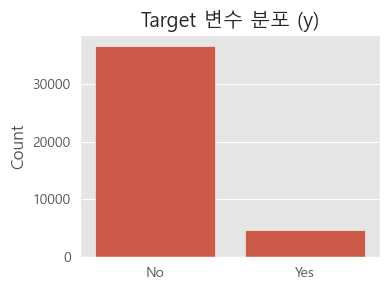

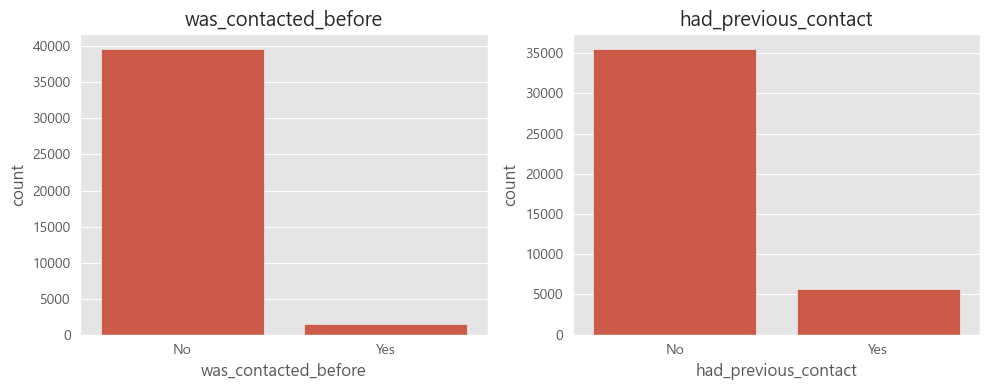

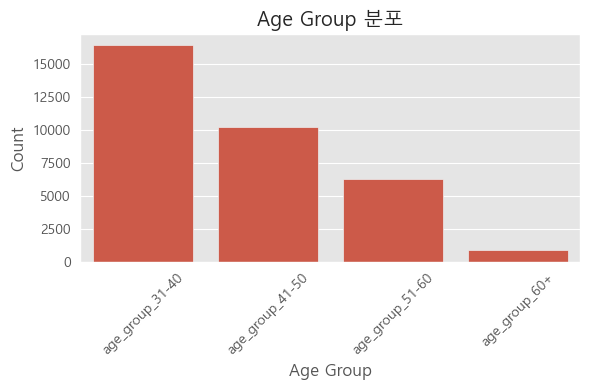

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# 스타일 설정
sns.set_palette("pastel")
plt.style.use('ggplot')

# ✅ 1. y (타겟) 분포 확인
plt.figure(figsize=(4, 3))
sns.countplot(x='y', data=df_cleaned)
plt.title("Target 변수 분포 (y)")
plt.xticks([0, 1], ['No', 'Yes'])
plt.ylabel("Count")
plt.xlabel("")
plt.tight_layout()
plt.show()

# ✅ 2. 주요 파생 변수 (이진) 확인
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x='was_contacted_before', data=df_cleaned, ax=axs[0])
axs[0].set_title("was_contacted_before")
axs[0].set_xticklabels(['No', 'Yes'])

sns.countplot(x='had_previous_contact', data=df_cleaned, ax=axs[1])
axs[1].set_title("had_previous_contact")
axs[1].set_xticklabels(['No', 'Yes'])

plt.tight_layout()
plt.show()

# ✅ 3. 나이 그룹 확인 (age_group 컬럼이 원핫일 경우)
age_cols = [col for col in df_cleaned.columns if col.startswith("age_group_")]

age_dist = df_cleaned[age_cols].sum().sort_index()

plt.figure(figsize=(6, 4))
sns.barplot(x=age_dist.index, y=age_dist.values)
plt.title("Age Group 분포")
plt.ylabel("Count")
plt.xlabel("Age Group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6. 데이터 저장
---

In [67]:
# 최종 전처리된 데이터 저장
processed_path = r'D:\python\코드잇 스프린트 데분\codeit-sprint-projects\sprint-missions\스프린트 미션 13\data\processed\bank_cleaned.csv'
df_cleaned.to_csv(processed_path, index=False)
print(f"클린 데이터 저장 완료: {processed_path}")

클린 데이터 저장 완료: D:\python\코드잇 스프린트 데분\codeit-sprint-projects\sprint-missions\스프린트 미션 13\data\processed\bank_cleaned.csv


In [68]:
df_cleaned['y']

0        0
1        0
2        0
3        0
4        0
        ..
41183    1
41184    0
41185    0
41186    1
41187    0
Name: y, Length: 41188, dtype: int64

In [ ]:
# 타겟(y)만 별도 파일로 저장
clean_y = df_cleaned['y']
clean_y_path = processed_path.replace('bank_cleaned.csv', 'clean_y.csv')
clean_y.to_csv(clean_y_path, index=False)
print(f"클린 y 저장 완료: {clean_y_path}")